In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
## IMPORT DATA

In [6]:
customers = pd.read_csv("olist_customers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
product_category_name_translation = pd.read_csv("product_category_name_translation.csv")

In [6]:
## MAIN

In [27]:
df_main = orders.merge(customers, on="customer_id",how="left").merge(payments, on="order_id", how="left")
df_main.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


In [9]:
df_main[["customer_unique_id", 
         "order_status",
         "customer_city",
         "customer_zip_code_prefix",
         "customer_state",
         "payment_type",
         "payment_value"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103887 entries, 0 to 103886
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   customer_unique_id        103887 non-null  object 
 1   order_status              103887 non-null  object 
 2   customer_city             103887 non-null  object 
 3   customer_zip_code_prefix  103887 non-null  int64  
 4   customer_state            103887 non-null  object 
 5   payment_type              103886 non-null  object 
 6   payment_value             103886 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 5.5+ MB


In [23]:
products = products[["product_id", "product_category_name"]]

In [21]:
df = order_items.merge(orders, on = "order_id", how="left").merge(products, on="product_id", how="left").merge(product_category_name_translation, on="product_category_name", how="left")

In [80]:
print(df.groupby("product_category_name_english")["order_id"].count().sort_values(ascending=False).head(5))

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
Name: order_id, dtype: int64


In [20]:
print( df_main[["order_id"]].count().sort_values(ascending=False).head(5) )   

order_id    103887
dtype: int64


In [22]:
df["profit"] = df["price"] - df["freight_value"]

In [82]:
print(df.groupby("product_category_name_english")["profit"].sum().sort_values(ascending=False).head(5))

product_category_name_english
watches_gifts            1104469.75
health_beauty            1076114.61
bed_bath_table            832295.64
sports_leisure            819441.46
computers_accessories     764636.24
Name: profit, dtype: float64


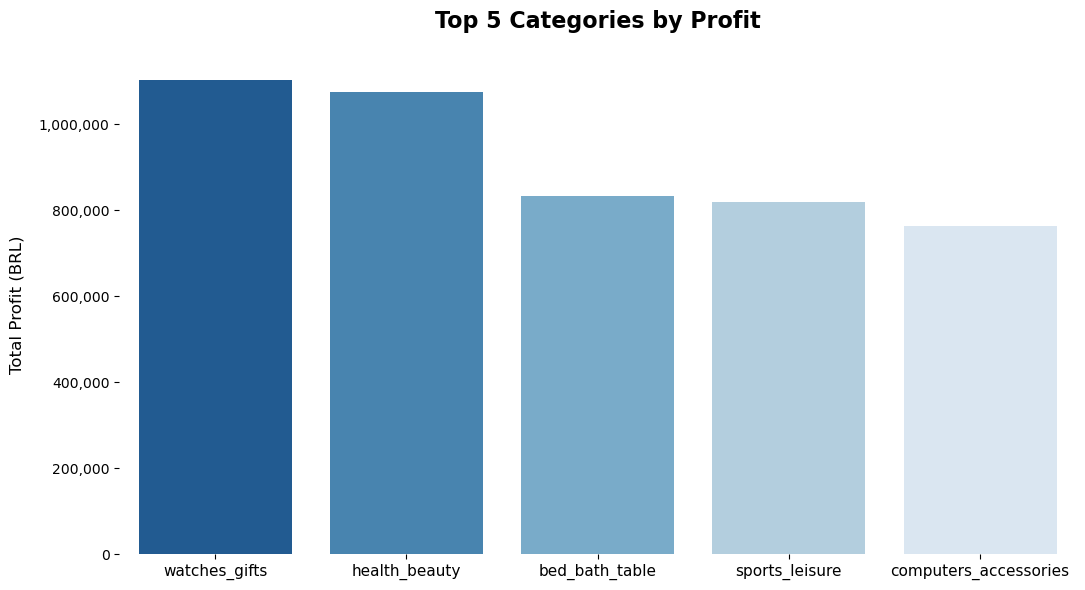

In [100]:
top5 = (df.groupby("product_category_name_english")["profit"]
        .sum()
        .sort_values(ascending=False)
        .head(5)
        .reset_index())

colors = sns.color_palette("Blues_r", n_colors=5)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(data=top5, x="product_category_name_english", y="profit", hue="product_category_name_english",
            palette=colors, legend=False, ax=ax)

sns.despine(left=True, bottom=True)
ax.set_title("Top 5 Categories by Profit", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("")
ax.set_ylabel("Total Profit (BRL)", fontsize=12, labelpad=10)
ax.tick_params(axis="x", labelsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()

In [101]:
print(df.groupby("product_id")["profit"].sum().sort_values(ascending=False).head(5))

product_id
bb50f2e236e5eea0100680137654686c    60163.90
6cdd53843498f92890544667809f1595    50366.41
d6160fb7873f184099d9bc95e30376af    47472.50
25c38557cf793876c5abdd5931f922db    37502.69
53b36df67ebb7c41585e8d54d6772e08    35408.91
Name: profit, dtype: float64


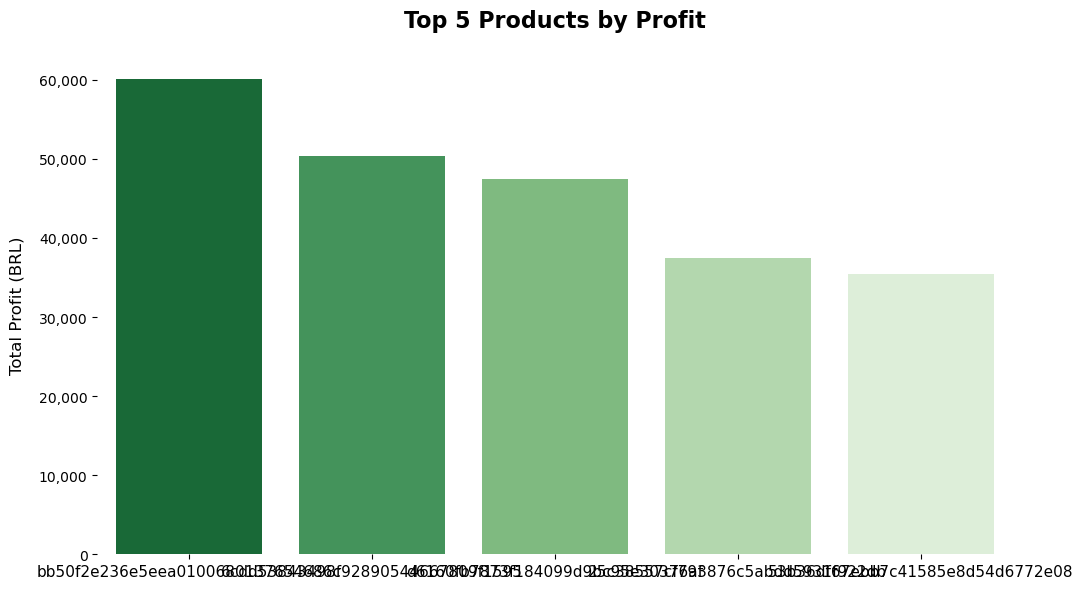

In [104]:
top5_products = (df.groupby("product_id")["profit"]
                .sum()
                .sort_values(ascending=False)
                .head(5)
                .reset_index())

colors = sns.color_palette("Greens_r", n_colors=5)

fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(data=top5_products, x="product_id", y="profit", hue="product_id",
            palette=colors, legend=False, ax=ax)

sns.despine(left=True, bottom=True)
ax.set_title("Top 5 Products by Profit", fontsize=16, fontweight="bold", pad=20)
ax.set_xlabel("")
ax.set_ylabel("Total Profit (BRL)", fontsize=12, labelpad=10)
ax.tick_params(axis="x", labelsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()